Part 2: Instructions and Guidelines

• Task: Build a Physics Informed Neural Network (PINN) to solve the Simple Harmonic Oscillator system.

• The system is governed by the differential equation: 𝒅𝟐x/𝒅𝒕𝟐 + 𝝎𝟐𝒙 = 𝟎

▪ In the above equation, x is the displacement and ω is the angular frequency.

▪ The typical initial conditions for the Simple Harmonic Oscillator are the initial position and the initial velocity of the oscillating mass.

– For this problem assume x = 0 at t=0 and v = 1 at t=0.

▪ Let the angular frequency ω = 2π (which basically means the time taken for 1 cycle is 1 sec).

▪ Solve the problem considering a time domain of 2 cycles, so, 0 to 2, and choose 1000 points in between t.

▪ With these pieces of information, you should be able to define the loss function as a combination of initial conditions loss and physics loss.

▪ Once the PINN is trained, run it over a bunch of test points of t from 0 to 1 sec. and plot the solution

▪ Finally, compare it with the analytical solution, by plotting it, which happens to be: 
𝒙(𝒕) = 𝑽0/𝝎 ∗ 𝒏𝒑.𝐬𝐢𝐧(𝝎 + 𝒕)

In [3]:
import matplotlib.pyplot as  plt
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np

In [4]:
# Define the Physics-Informed Neural Network (PINN)
class PINN_SHO(nn.Module):
    #Create the nueral network, 1 nuernon ->128->128-> 1 output
    def __init__(self):
        super(PINN_SHO, self).__init__()
        self.fc1 = nn.Linear(1, 128)  # Input is time t
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)  # Output is the displacement
    #Used Relu at first but tanh seemed to be more accurate training the model
    def forward(self, t):
        x = torch.tanh(self.fc1(t))
        x = torch.tanh(self.fc2(x))
        displacement = self.fc3(x)
        return displacement

In [5]:
#define the initial parameters
x0 = 0
v0 = 1
w = 2*(math.pi)

In [8]:


# Define the Physics-Informed Loss function
def physics_loss(model, t):
    # Predict the displacement over time 
    x_pred  = model(t)
    
    dx_dt = torch.autograd.grad(x_pred, t, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(dx_dt, t, grad_outputs=torch.ones_like(dx_dt), create_graph=True)[0]
    
    #Residual
    residual = d2x_dt2 + (w ** 2) * x_pred
    return torch.mean(residual**2)
    
def initial_condition_loss(model):
    t0 = torch.tensor([[0.0]], requires_grad=True)  # t = 0
    x0_pred = model(t0)
    
    # Compute derivative for velocity
    dx0_pred = torch.autograd.grad(x0_pred, t0, grad_outputs=torch.ones_like(x0_pred), create_graph=True)[0]
    
    # x(0) = 0, v(0) = 1
    pos_loss = torch.mean((x0_pred - x0)**2)
    vel_loss = torch.mean((dx0_pred - v0)**2)
    
    #initial condition loss according to initial pos = 0, v = 1
    return pos_loss + vel_loss

# Train the PINN model
def train_PINN(model, epochs=10000, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    #Training loop
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        #Create Training data using rand samples
        t = torch.rand(1000, 1) * 2  # Random time samples between 0 and 2
        
        #Allow derivatives to be taken
        t.requires_grad = True

        # Physics loss + initial loss
        loss = physics_loss(model, t) + initial_condition_loss(model)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        if epoch % 500 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')





In [9]:
pinn = PINN_SHO()

# Train the model
train_PINN(pinn, epochs=10000)

Epoch 0, Loss: 8.51231575012207
Epoch 500, Loss: 0.8131262063980103
Epoch 1000, Loss: 0.7224245071411133
Epoch 1500, Loss: 0.6448949575424194
Epoch 2000, Loss: 0.5219194889068604
Epoch 2500, Loss: 0.4665879011154175
Epoch 3000, Loss: 0.38783544301986694
Epoch 3500, Loss: 0.413855642080307
Epoch 4000, Loss: 0.42860645055770874
Epoch 4500, Loss: 0.36761778593063354
Epoch 5000, Loss: 0.35106906294822693
Epoch 5500, Loss: 0.3390810787677765
Epoch 6000, Loss: 0.31627896428108215
Epoch 6500, Loss: 0.30173569917678833
Epoch 7000, Loss: 0.20153287053108215
Epoch 7500, Loss: 0.1542922705411911
Epoch 8000, Loss: 0.03776499629020691
Epoch 8500, Loss: 0.03298149257898331
Epoch 9000, Loss: 0.014059176668524742
Epoch 9500, Loss: 0.007996849715709686


In [15]:
#Gather input (time) and output (position) values to plot
inp = []
out = []
for i in range(0,100):
    inp.append(i/100)
    with torch.no_grad():
        i = torch.tensor([i/100]).float()
        o = pinn(i)
        o = o.numpy()
        out.append(o)

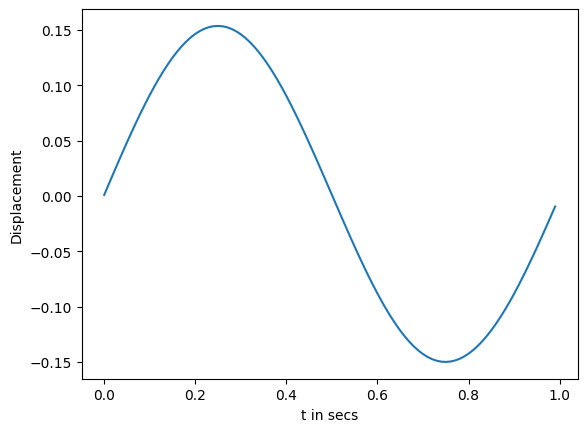

In [16]:
#Plot the PINN function after training

plt.plot(inp,out)

plt.xlabel('t in secs')
plt.ylabel('Displacement')

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

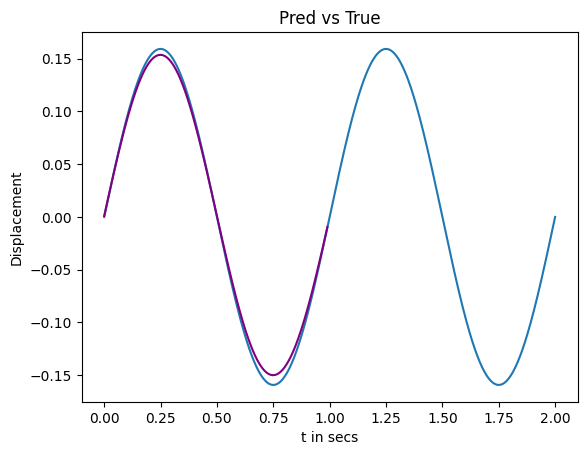

In [17]:
#Plot the predicted values from PINN against the true values from the given equation
t = np.linspace(0,2,1000)
x = v0/w *np.sin(w*t)
plt.plot(t,x)
plt.plot(inp, out, label='PINN Prediction', color='purple')
plt.xlabel('t in secs')
plt.ylabel('Displacement')
plt.title('Pred vs True')
plt.show